# Project 2: Medical Route Optimization

This notebook demonstrates the Genetic Algorithm solution for the Vehicle Routing Problem (VRP) in a medical delivery context.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
import random
from src.models.location import Location
from src.models.vehicle import Vehicle
from src.algorithms.genetic_optimizer import GeneticOptimizer
from src.utils.plotter import Plotter
from src.llm.report_generator import ReportGenerator
from src.utils.data_loader import DataLoader

/Users/rogeriobrumhermany/Projects/fiap/tsp/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# 1. Define Problem Data
depot = Location(0, 50, 50, "Central Depot", type='depot')

NUM_LOCATIONS = 40

locations = DataLoader.load_data(limit=NUM_LOCATIONS, data_dir='../data')

# Create Fleet
# Estimate required capacity
deliveries = [l for l in locations if getattr(l, 'type', 'delivery') == 'delivery']
total_demand = sum(l.demand for l in deliveries)
num_vehicles = 6

fleet = []
total_capacity = 0
total_distance = 0
for i in range(num_vehicles):
    capacity = random.randint(3, 6)
    total_capacity += capacity
    max_distance = random.randint(100, 200)
    total_distance += max_distance
    fleet.append(Vehicle(id=i+1, capacity=capacity, max_distance=max_distance))

print(f"Loaded {NUM_LOCATIONS} locations from dataset and {len(locations) - NUM_LOCATIONS} gas stations.")
print(f"Created Fleet of {len(fleet)} vehicles with total load capacity of {total_capacity} and total autonomy distance of {total_distance}")
print("Fleet: ")
for vehicle in fleet:
    print(f"Vehicle {vehicle.id} has a capacity of {vehicle.capacity} and a max distance of {vehicle.max_distance}")

Loaded 40 locations from dataset and 10 gas stations.
Created Fleet of 6 vehicles with total load capacity of 26 and total autonomy distance of 843
Fleet: 
Vehicle 1 has a capacity of 4 and a max distance of 161
Vehicle 2 has a capacity of 5 and a max distance of 118
Vehicle 3 has a capacity of 3 and a max distance of 106
Vehicle 4 has a capacity of 4 and a max distance of 182
Vehicle 5 has a capacity of 5 and a max distance of 115
Vehicle 6 has a capacity of 5 and a max distance of 161


In [ ]:
# 2. Run Genetic Algorithm
# Adjust generations/pop_size based on problem size if needed
locations_times_vehicles = NUM_LOCATIONS * num_vehicles
generations = locations_times_vehicles * 4 
pop_size = int(locations_times_vehicles * 0.12)
early_stopping_rounds = int(pop_size / 2)


optimizer = GeneticOptimizer(locations, depot, fleet, generations=generations, pop_size=pop_size, early_stopping_rounds=early_stopping_rounds, priority_weight=0.5)
best_routes, best_dist, fitness_history = optimizer.run()

print(f"Best Total Distance: {best_dist:.2f}")

Stopping early at generation 189 due to no improvement for 14 rounds.
Best Total Distance: 1432.96


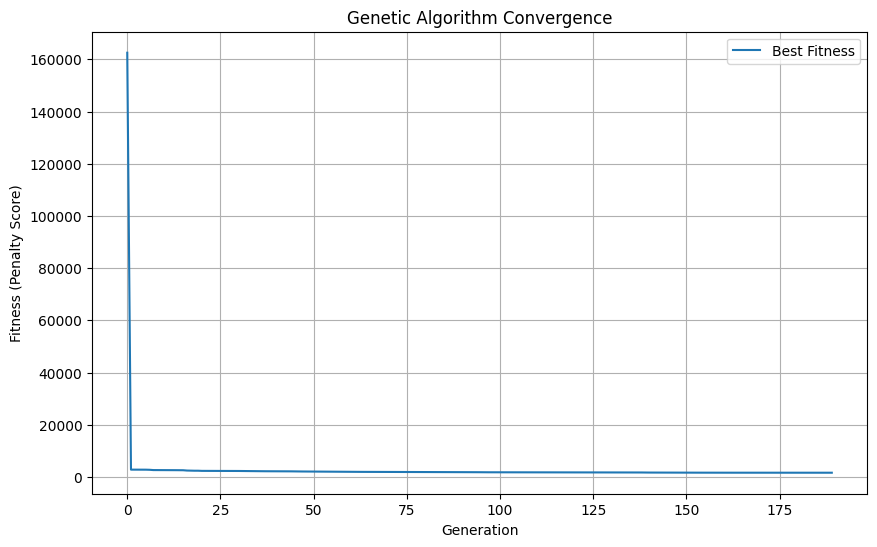

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(fitness_history, label='Best Fitness')
plt.title('Genetic Algorithm Convergence')
plt.xlabel('Generation')
plt.ylabel('Fitness (Penalty Score)')
plt.grid(True)
plt.legend()
plt.show()

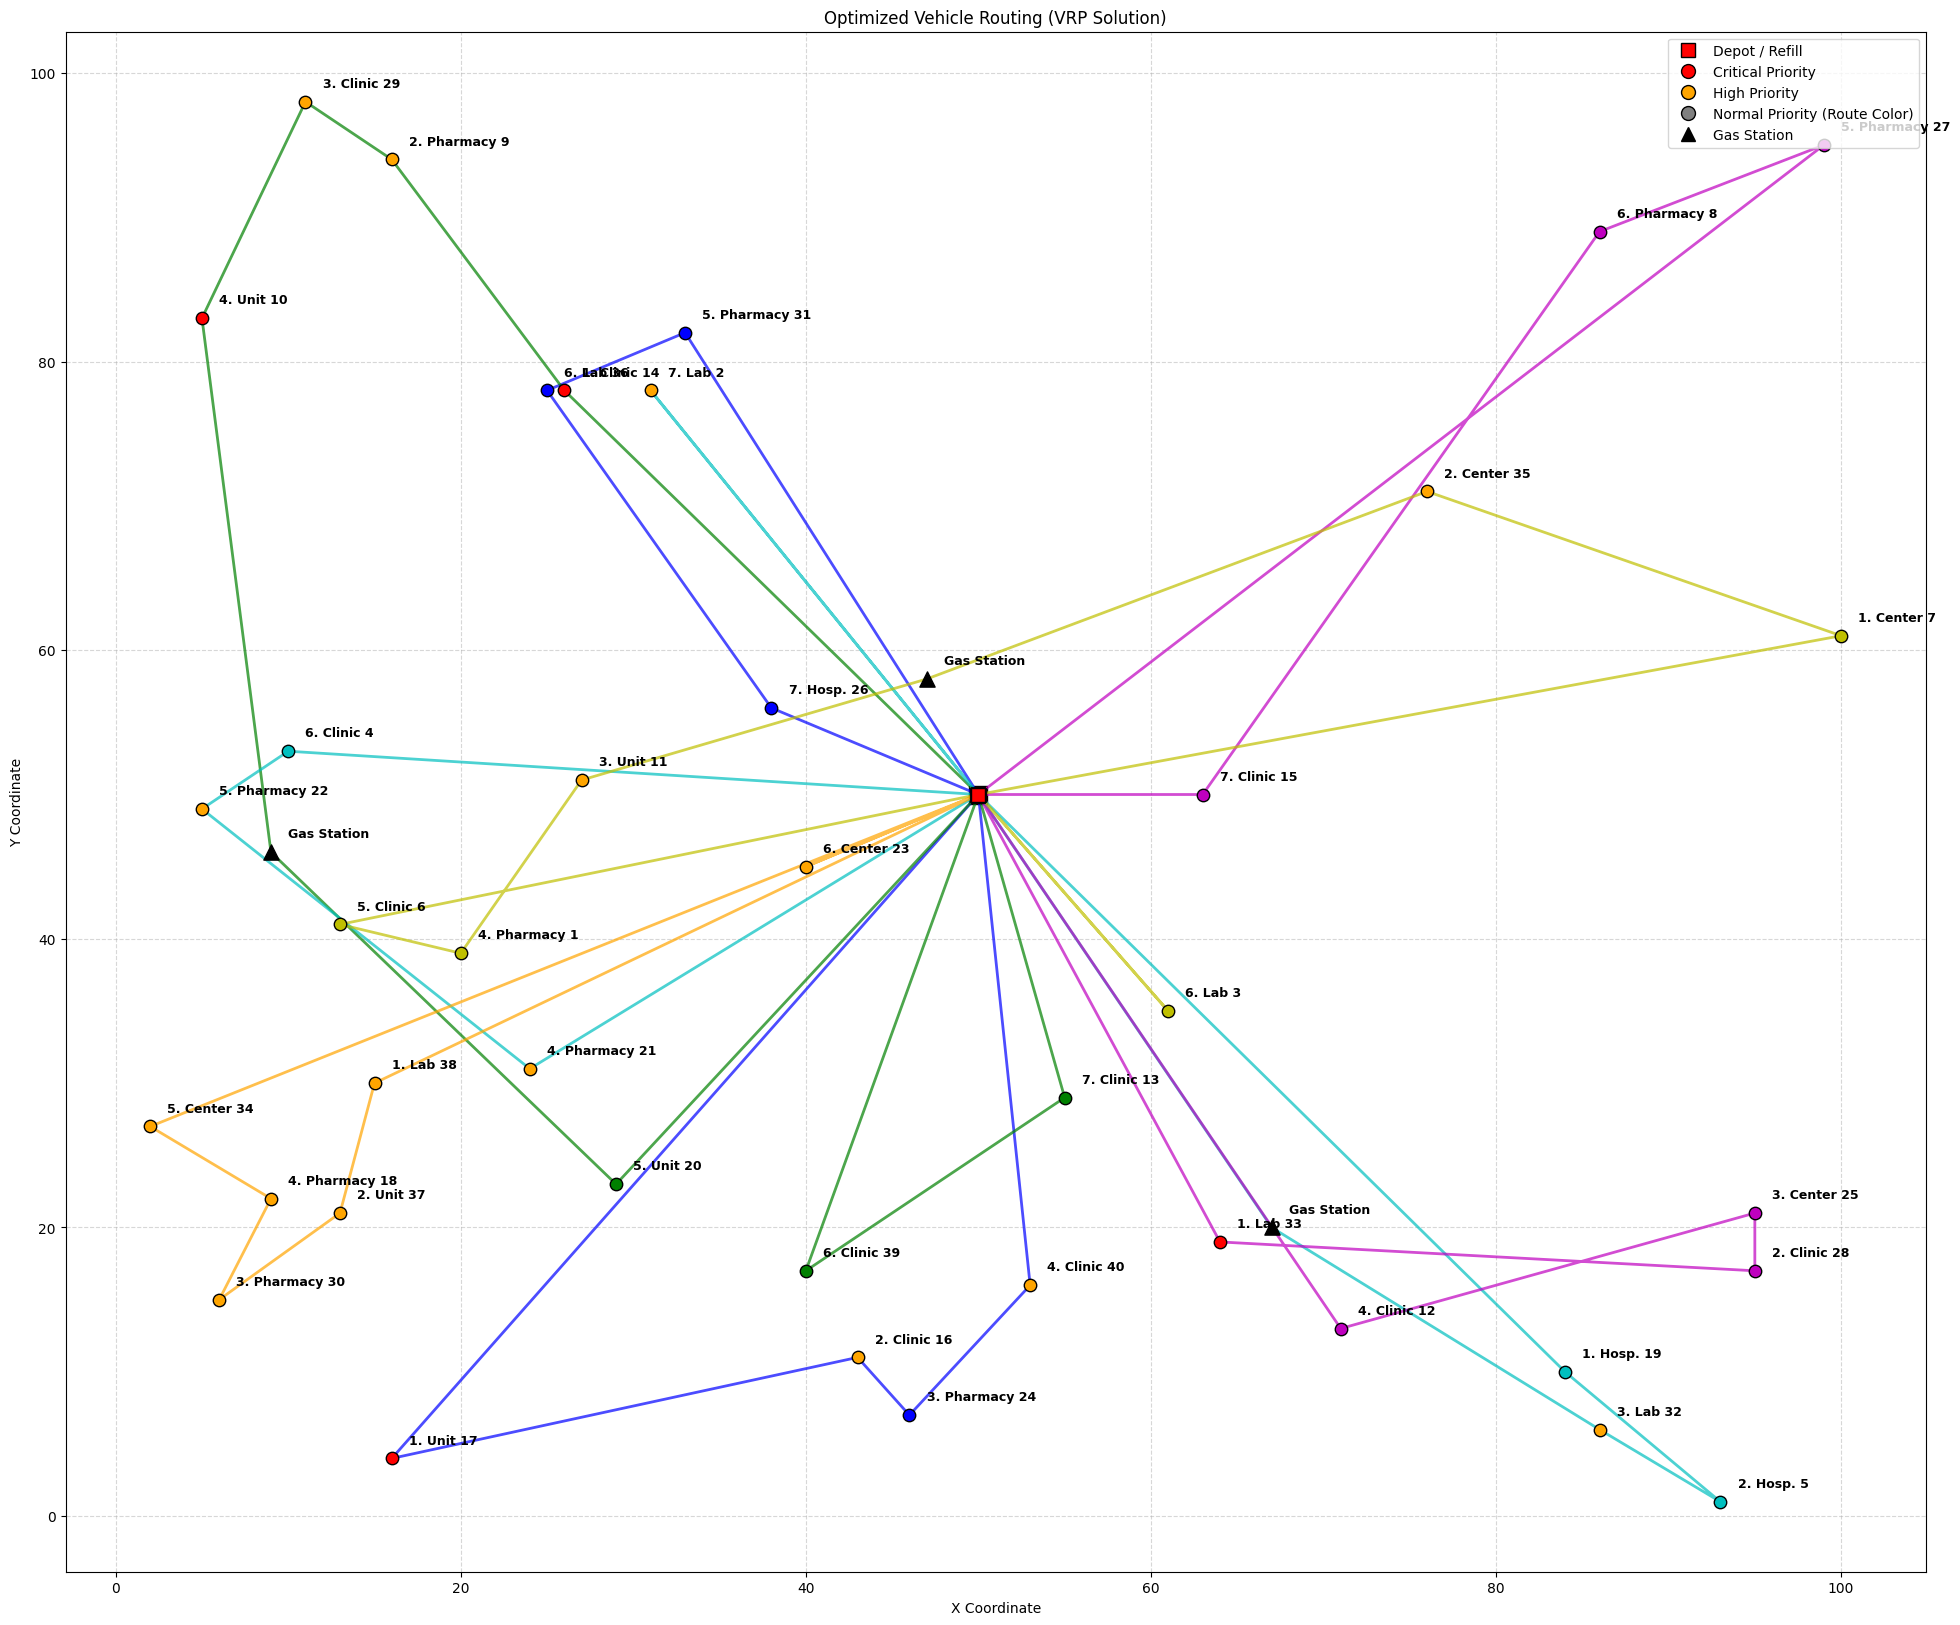

In [7]:
# 3. Visualize Solution
Plotter.plot_solution(best_routes, depot)

In [ ]:
# 4. Generate LLM Report
llm = ReportGenerator() # Will use mock if no API key

print("Generating Instructions for Drivers...\n")

max_reports = 10

for i, route in enumerate(best_routes[:max_reports]):
    print(llm.generate_driver_instructions(i, route))
    print("\n" + "="*40 + "\n")

if len(best_routes) > max_reports:
    print(f"... and {len(best_routes) - max_reports} more routes.")

Loading local model: Qwen/Qwen2.5-3B-Instruct...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use mps


Model loaded successfully.
Generating Instructions for Drivers...

Hey there,

Good morning from the office! 

Head out to Unit 17 (High Priority), then go straight to Clinic 16 (Immediate Priority) 🏥. After that, swing by Pharmacy 24 (Normal Priority) 🏫. Next stop is Clinic 40 (Immediate Priority) 🏥. Then head over to Central Depot. First up is Pharmacy 31 (Normal Priority) 🏫. Lab 36 and Hosp. 26 are also Normal Priority 🏫🏥.

And don’t forget to give Central Depot another loop with those stops. And that’s all for today!

Stay safe out there, but not too safe! 😎

Driver Boss


Hey there,

Good morning! Here’s your run for today:

- Clinic 14 (High priority)
- Pharmacy 9 (Immediate priority)
- Clinic 29 (Immediate priority)
- Unit 10 (High priority)
Gas Station 3
- Unit 20 (Normal priority)
Central Depot
- Clinic 39 (Normal priority)
- Clinic 13 (Normal priority)
Central Depot

Remember to be extra careful out there today. Safe travels!

Talk later!


Hey there,

Morning out on the road